# ==========================================================
# Handwritten Digit Recognition using CNN (MNIST) with PyTorch
# ==========================================================
#
# Project Type:
# Deep Learning Project using CNN and PyTorch
#
# Objective:
# Build and train a Convolutional Neural Network (CNN)
# to classify handwritten digits (0–9) using the MNIST dataset.
#
# ==========================================================

# Import Required Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from torch.utils.data import random_split

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Device Configuration

In [2]:


# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


# Data Preprocessing and Transformations
# Load MNIST Dataset

In [3]:
# ==========================================================
# Data Preprocessing and Transformations
# ==========================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    # Normalize MNIST dataset
    transforms.Normalize((0.5,), (0.5,))
])

# ==========================================================
# Load MNIST Dataset
# ==========================================================

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Training Dataset Size:", len(train_dataset))
print("Testing Dataset Size:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.9MB/s]

Training Dataset Size: 60000
Testing Dataset Size: 10000


# Split Training Dataset into:
# Training Set and Validation Set

In [5]:

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Training Set Size:", len(train_data))
print("Validation Set Size:", len(val_data))

Training Set Size: 48000
Validation Set Size: 12000


#Visualize Sample Images

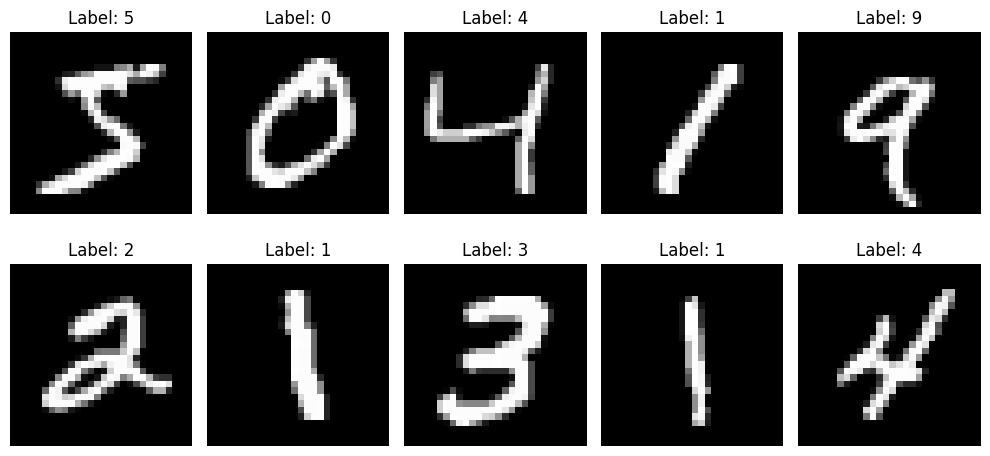

In [6]:

# Display Sample Images


plt.figure(figsize=(10,5))

for i in range(10):

    image, label = train_dataset[i]

    plt.subplot(2,5,i+1)

    plt.imshow(image.squeeze(), cmap='gray')

    plt.title(f"Label: {label}")

    plt.axis('off')

plt.tight_layout()
plt.show()

Build CNN Model

In [7]:
# ==========================================================
# CNN Model Definition
# ==========================================================

class CNNModel(nn.Module):

    def __init__(self):

        super(CNNModel, self).__init__()

        # First Convolutional Layer
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Second Convolutional Layer
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Max Pooling Layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Dropout Layer
        self.dropout = nn.Dropout(0.5)

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)

        self.fc2 = nn.Linear(128, 10)

        # ReLU Activation
        self.relu = nn.ReLU()

    def forward(self, x):

        # First Convolution Block
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # Second Convolution Block
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully Connected Layer
        x = self.fc1(x)
        x = self.relu(x)

        # Dropout
        x = self.dropout(x)

        # Output Layer
        x = self.fc2(x)

        return x

Model Summary

In [8]:
# ==========================================================
# Initialize Model
# ==========================================================

model = CNNModel().to(device)

print(model)

CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


Training Function

In [10]:
# ==========================================================
# Training Function
# ==========================================================

def train_model(model, train_loader, val_loader, optimizer, epochs=10):

    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # ==================================================
        # Training Phase
        # ==================================================

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Clear gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            running_loss += loss.item()

            # Predictions
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)

        train_accuracy = 100 * correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # ==================================================
        # Validation Phase
        # ==================================================

        model.eval()

        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)

                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)

        val_accuracy = 100 * correct / total

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # ==================================================
        # Print Epoch Results
        # ==================================================

        print(f"Epoch [{epoch+1}/{epochs}]")

        print(f"Train Loss: {train_loss:.4f}")

        print(f"Train Accuracy: {train_accuracy:.2f}%")

        print(f"Validation Loss: {val_loss:.4f}")

        print(f"Validation Accuracy: {val_accuracy:.2f}%")

        print("-" * 50)

    return train_losses, val_losses, train_accuracies, val_accuracies

Experiment 1

Optimizer: Adam

Batch Size: 64

In [11]:
# ==========================================================
# Create DataLoaders for Experiment 1
# ==========================================================

train_loader_1 = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

val_loader_1 = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False
)

test_loader_1 = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# ==========================================================
# Initialize Model
# ==========================================================

model_adam = CNNModel().to(device)

# Adam Optimizer
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)

# ==========================================================
# Train Model
# ==========================================================

adam_results = train_model(
    model_adam,
    train_loader_1,
    val_loader_1,
    optimizer_adam,
    epochs=10
)

Epoch [1/10]
Train Loss: 0.2781
Train Accuracy: 91.31%
Validation Loss: 0.0751
Validation Accuracy: 97.64%
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.0929
Train Accuracy: 97.17%
Validation Loss: 0.0526
Validation Accuracy: 98.33%
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.0715
Train Accuracy: 97.91%
Validation Loss: 0.0436
Validation Accuracy: 98.67%
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.0571
Train Accuracy: 98.30%
Validation Loss: 0.0389
Validation Accuracy: 98.86%
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.0473
Train Accuracy: 98.56%
Validation Loss: 0.0434
Validation Accuracy: 98.73%
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.0401
Train Accuracy: 98.76%
Validation Loss: 0.0377
Validation Accuracy: 98.97%
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.0351
Train Accuracy: 98.9

Experiment 2

Optimizer: SGD

Batch Size: 128

In [12]:
# ==========================================================
# Create DataLoaders for Experiment 2
# ==========================================================

train_loader_2 = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True
)

val_loader_2 = DataLoader(
    val_data,
    batch_size=128,
    shuffle=False
)

test_loader_2 = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

# ==========================================================
# Initialize Model
# ==========================================================

model_sgd = CNNModel().to(device)

# SGD Optimizer
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)

# ==========================================================
# Train Model
# ==========================================================

sgd_results = train_model(
    model_sgd,
    train_loader_2,
    val_loader_2,
    optimizer_sgd,
    epochs=10
)

Epoch [1/10]
Train Loss: 1.8217
Train Accuracy: 45.77%
Validation Loss: 0.8141
Validation Accuracy: 81.33%
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.6384
Train Accuracy: 80.31%
Validation Loss: 0.3550
Validation Accuracy: 90.12%
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.3986
Train Accuracy: 88.15%
Validation Loss: 0.2469
Validation Accuracy: 92.79%
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.3093
Train Accuracy: 90.90%
Validation Loss: 0.1983
Validation Accuracy: 94.30%
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.2504
Train Accuracy: 92.73%
Validation Loss: 0.1638
Validation Accuracy: 95.01%
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.2152
Train Accuracy: 93.82%
Validation Loss: 0.1422
Validation Accuracy: 95.73%
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.1900
Train Accuracy: 94.4

Evaluation Function

In [13]:
# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate_model(model, test_loader):

    criterion = nn.CrossEntropyLoss()

    model.eval()

    test_loss = 0.0

    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())

            all_predictions.extend(predicted.cpu().numpy())

    avg_loss = test_loss / len(test_loader)

    accuracy = 100 * correct / total

    return avg_loss, accuracy, all_labels, all_predictions

Evaluate Experiment 1

In [14]:
# ==========================================================
# Evaluate Adam Model
# ==========================================================

adam_loss, adam_accuracy, adam_labels, adam_predictions = evaluate_model(
    model_adam,
    test_loader_1
)

print("Experiment 1 - Adam Optimizer")

print(f"Test Loss: {adam_loss:.4f}")

print(f"Test Accuracy: {adam_accuracy:.2f}%")

Experiment 1 - Adam Optimizer
Test Loss: 0.0283
Test Accuracy: 99.23%


Evaluate Experiment 2

In [15]:
# ==========================================================
# Evaluate SGD Model
# ==========================================================

sgd_loss, sgd_accuracy, sgd_labels, sgd_predictions = evaluate_model(
    model_sgd,
    test_loader_2
)

print("Experiment 2 - SGD Optimizer")

print(f"Test Loss: {sgd_loss:.4f}")

print(f"Test Accuracy: {sgd_accuracy:.2f}%")

Experiment 2 - SGD Optimizer
Test Loss: 0.0804
Test Accuracy: 97.44%


Results Comparison Table

In [16]:
# ==========================================================
# Create Results DataFrame
# ==========================================================

results_df = pd.DataFrame({

    "Model": ["Model A", "Model B"],

    "Optimizer": ["Adam", "SGD"],

    "Batch Size": [64, 128],

    "Accuracy": [adam_accuracy, sgd_accuracy],

    "Loss": [adam_loss, sgd_loss]
})

results_df

,Model,Optimizer,Batch Size,Accuracy,Loss
0,Model A,Adam,64,99.23,0.028255
1,Model B,SGD,128,97.44,0.080396


Accuracy Curves

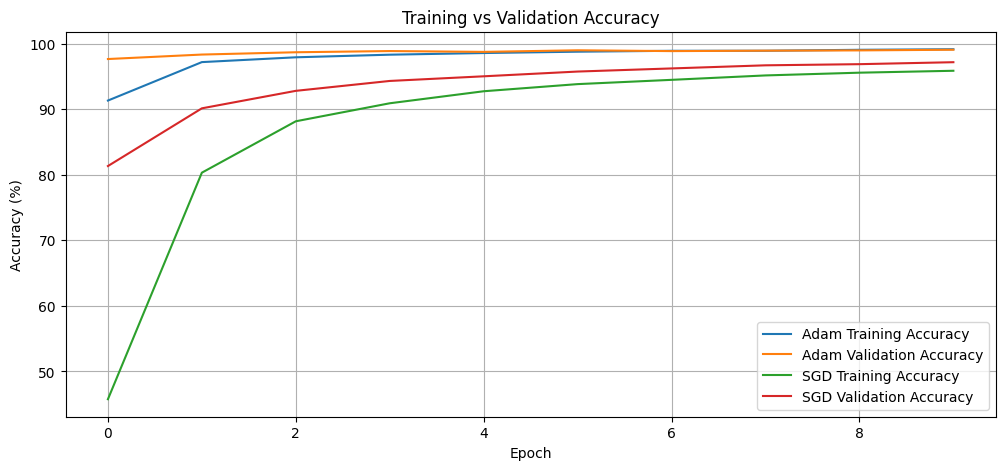

In [17]:
# ==========================================================
# Plot Accuracy Curves
# ==========================================================

adam_train_losses, adam_val_losses, adam_train_acc, adam_val_acc = adam_results

sgd_train_losses, sgd_val_losses, sgd_train_acc, sgd_val_acc = sgd_results

plt.figure(figsize=(12,5))

plt.plot(adam_train_acc, label='Adam Training Accuracy')

plt.plot(adam_val_acc, label='Adam Validation Accuracy')

plt.plot(sgd_train_acc, label='SGD Training Accuracy')

plt.plot(sgd_val_acc, label='SGD Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()

Loss Curves

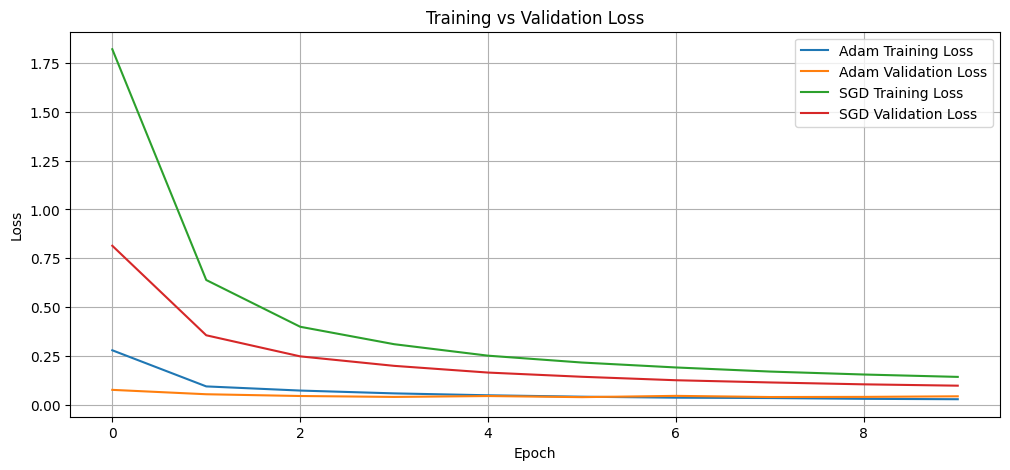

In [18]:
# ==========================================================
# Plot Loss Curves
# ==========================================================

plt.figure(figsize=(12,5))

plt.plot(adam_train_losses, label='Adam Training Loss')

plt.plot(adam_val_losses, label='Adam Validation Loss')

plt.plot(sgd_train_losses, label='SGD Training Loss')

plt.plot(sgd_val_losses, label='SGD Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

Classification Report

In [19]:
# ==========================================================
# Classification Report for Adam Model
# ==========================================================

print("Classification Report:\n")

print(classification_report(adam_labels, adam_predictions))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       0.99      1.00      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.98      1.00      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Confusion Matrix

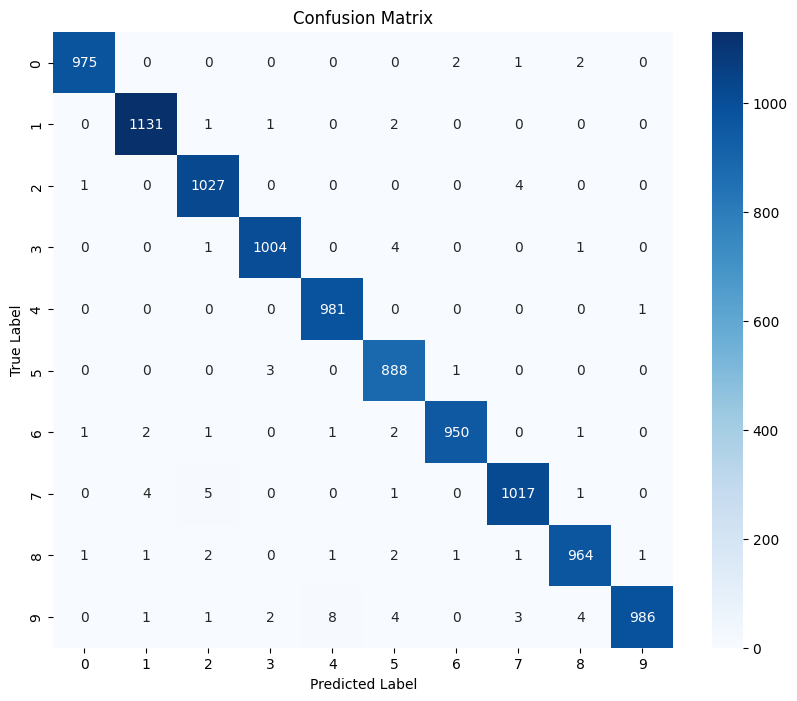

In [20]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(adam_labels, adam_predictions)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

Sample Predictions Visualization

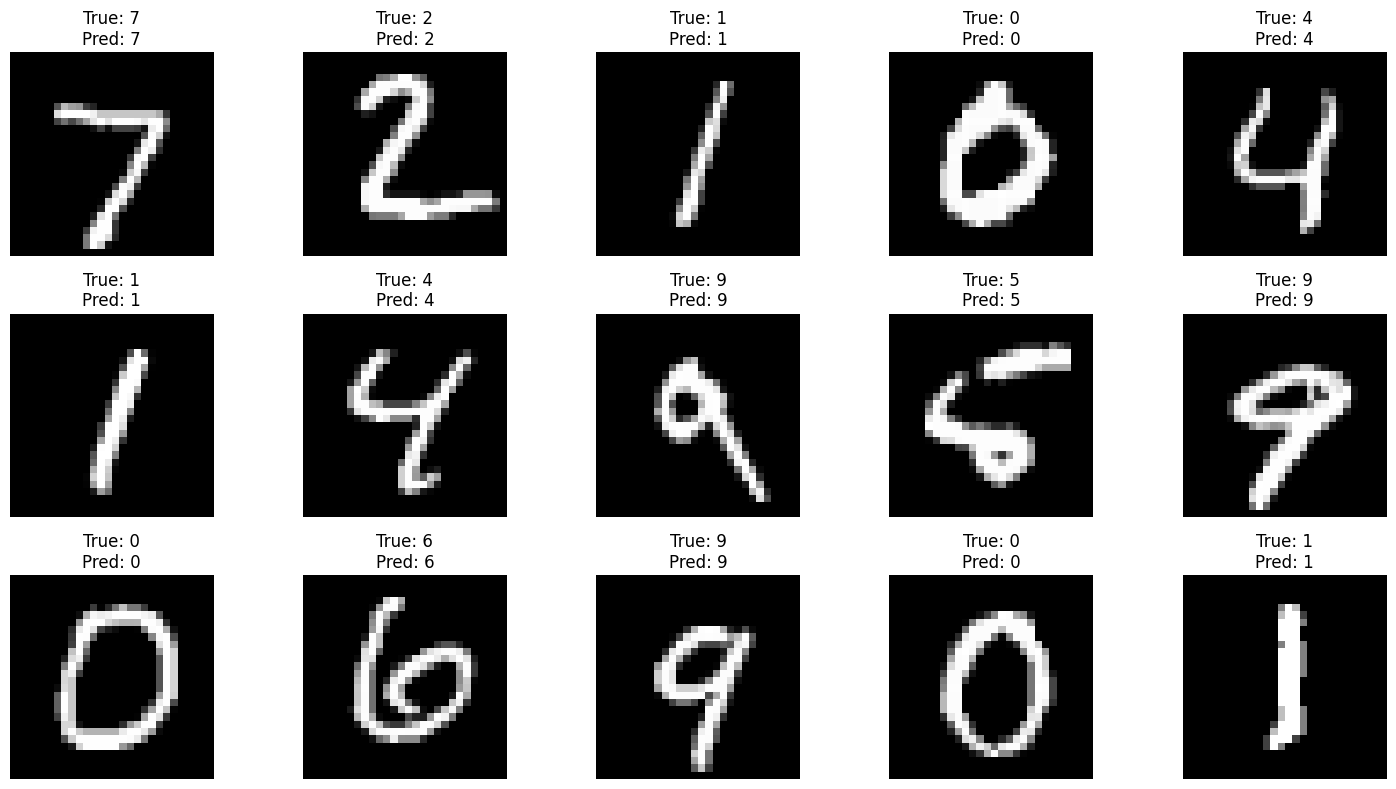

In [21]:
# ==========================================================
# Visualize Random Predictions
# ==========================================================

examples = iter(test_loader_1)

example_images, example_labels = next(examples)

example_images = example_images.to(device)

outputs = model_adam(example_images)

_, predictions = torch.max(outputs, 1)

example_images = example_images.cpu()

plt.figure(figsize=(15,8))

for i in range(15):

    plt.subplot(3,5,i+1)

    image = example_images[i].squeeze()

    plt.imshow(image, cmap='gray')

    plt.title(
        f"True: {example_labels[i]}\nPred: {predictions[i].item()}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

Save Trained Model

In [22]:
# ==========================================================
# Save Model
# ==========================================================

torch.save(model_adam.state_dict(), "mnist_cnn_pytorch.pth")

print("Model saved successfully!")

Model saved successfully!


Load Saved Model

In [23]:
# ==========================================================
# Load Saved Model
# ==========================================================

loaded_model = CNNModel().to(device)

loaded_model.load_state_dict(
    torch.load("mnist_cnn_pytorch.pth")
)

loaded_model.eval()

print("Model loaded successfully!")

Model loaded successfully!


Optimizer Comparison Discussion

In [24]:
# ==========================================================
# Discussion
# ==========================================================

print("Experiment Comparison:\n")

print("1. Adam Optimizer:")
print("- Faster convergence")
print("- Higher accuracy")
print("- Adaptive learning rate")

print("\n2. SGD Optimizer:")
print("- Slower convergence")
print("- Simpler optimization approach")
print("- Requires more tuning")

print("\nConclusion:")
print("Adam generally performs better on MNIST because")
print("it adapts learning rates automatically and")
print("converges faster than SGD.")

Experiment Comparison:

1. Adam Optimizer:
- Faster convergence
- Higher accuracy
- Adaptive learning rate

2. SGD Optimizer:
- Slower convergence
- Simpler optimization approach
- Requires more tuning

Conclusion:
Adam generally performs better on MNIST because
it adapts learning rates automatically and
converges faster than SGD.
